# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**DenseNet-169 Augmented Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a DenseNet-169 model on the Pneumonia dataset with data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [2]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.densenet_utils import build_densenet169_model
from utils.train_utils import get_callbacks
from utils.eval_utils import evaluate_model, compare_models
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix

# Core Variables

In [ ]:
# Global variables
DATA_PATH = '../data/'
MODEL_PATH = '../models/'
MODEL_NAME = 'densenet_169_augmented' # Name of the model to be saved

# Training parameters
BATCH_SIZE = 32 # + 64 and 128
EPOCHS = 100
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.5 # + 0.3 and costum sheduler
DROPOUT_RATE_START = 0.5
DROPOUT_RATE_END = 0.3
MODE = 'max'
CHOSEN_METRIC = 'val_AUC' # Metric to be used for model selection, e.g. 'val_loss', 'val_AUC', 'val_accuracy'
SEED = 42

FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_b{BATCH_SIZE}_lr{LEARNING_RATE}_pneumonia_model.keras'

# Data Loading & Preprocessing

In [ ]:
train_dataset, (test_images, test_labels), (val_images, val_labels) = load_and_preprocess_data(
        DATA_PATH,
        augment=True,
        batch_size=BATCH_SIZE,
        seed=SEED
    )


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)

Applying data augmentation to training data...


# DenseNet-169 Model

## Creation & Compilation

In [5]:
# Create and compile model
model = build_densenet169_model(dropout_rate=DROPOUT_RATE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 3)           │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resizing (Resizing)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ densenet169 (Functional)             │ (None, 7, 7, 1664)          │      12,642,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1664)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1664)                │           6,656 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         852,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc (Dense)                           │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,505,096 (51.52 MB)

 Trainable params: 857,864 (3.27 MB)

 Non-trainable params: 12,647,232 (48.25 MB)

In [ ]:
# dropout_scheduler = DropoutRateScheduler(dropout_start=DROPOUT_RATE_START, dropout_end=DROPOUT_RATE_END, epochs=EPOCHS)

## Training

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 166s 719ms/step - AUC: 0.9030 - accuracy: 0.8379 - loss: 0.4411 - val_AUC: 0.9415 - val_accuracy: 0.8340 - val_loss: 0.3552 - learning_rate: 0.0010
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 35s 233ms/step - AUC: 0.9669 - accuracy: 0.9176 - loss: 0.2280 - val_AUC: 0.9751 - val_accuracy: 0.9332 - val_loss: 0.2325 - learning_rate: 0.0010
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 34s 228ms/step - AUC: 0.9669 - accuracy: 0.9248 - loss: 0.2171 - val_AUC: 0.9777 - val_accuracy: 0.9256 - val_loss: 0.1995 - learning_rate: 0.0010
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 31s 207ms/step - AUC: 0.9743 - accuracy: 0.9241 - loss: 0.1959 - val_AUC: 0.9752 - val_accuracy: 0.9294 - val_loss: 0.1994 - learning_rate: 0.0010
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 43s 218ms/step - AUC: 0.9753 - accuracy: 0.9288 - loss: 0.1839 - val_AUC: 0.9672 - val_accuracy: 0.9008 - val_loss: 0.2370 - learning_rate: 0.0010
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 40s 209ms/step - AUC: 0.

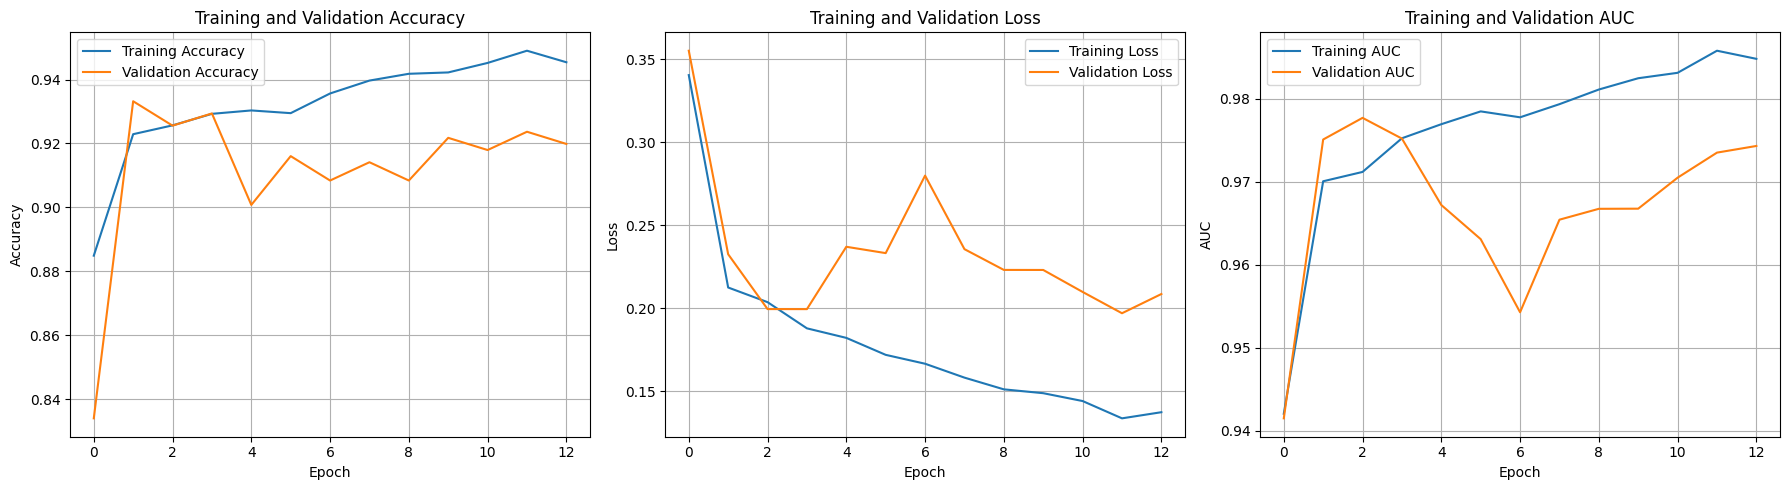

In [ ]:
# Train model
history = model.fit(
        train_dataset,
        validation_data=(val_images, val_labels),
        epochs=EPOCHS
    )

# Plot training history
plot_training_history(history)

# Save final model
model.save(FINAL_MODEL_PATH)

## Evaluation

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 938ms/step - AUC: 0.9073 - accuracy: 0.8213 - loss: 0.3970
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 949ms/step


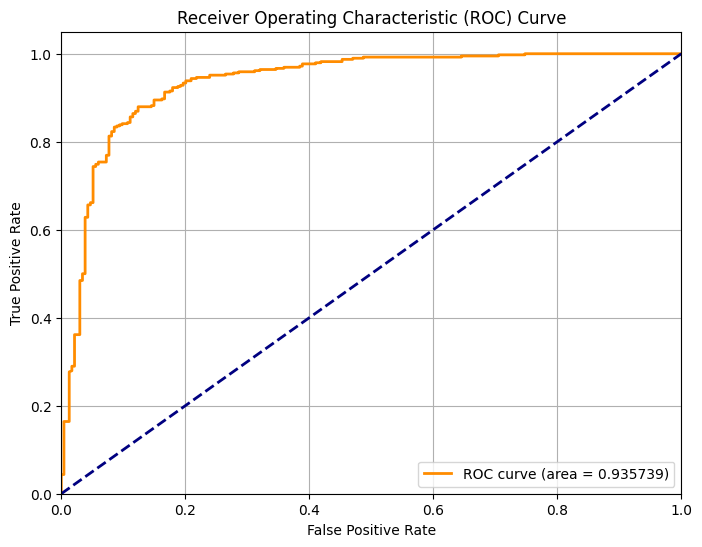

ROC AUC Score: 0.9357


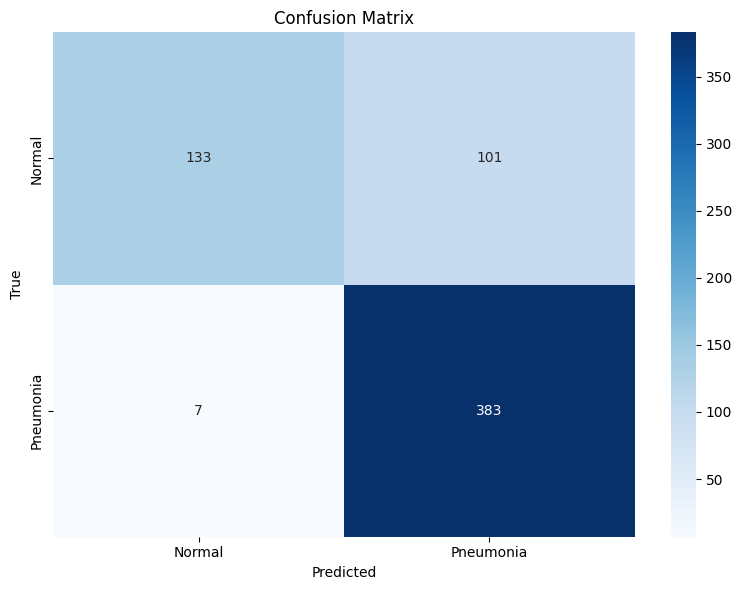

              precision    recall  f1-score   support

      Normal       0.95      0.57      0.71       234
   Pneumonia       0.79      0.98      0.88       390

    accuracy                           0.83       624
   macro avg       0.87      0.78      0.79       624
weighted avg       0.85      0.83      0.81       624



In [8]:
# Evaluate model
results = evaluate_model(model, test_images, test_labels)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])